In [2]:
pip install numpy pandas matplotlib scikit-learn hmmlearn cvxpy yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.3 MB/s eta 0:00:00


# Regime-Shift: Macro-Aware Tactical Asset Allocation Engine
### Summer of Quant — Advanced Capstone

**Pipeline:** data &rarr; features &rarr; HMM regime detection &rarr; walk-forward validation &rarr; convex portfolio optimization (cvxpy) &rarr; cost-aware backtest &rarr; results.

**Data:** Nifty 50 (`^NSEI`), Gold futures (`GC=F`), a 7-10Y Treasury bond ETF (`IEF`) as the bonds leg, and India VIX (`^INDIAVIX`, falling back to `^VIX` only if unavailable) — all pulled live via `yfinance`. `IEF` is used instead of a raw yield series (e.g. `^TNX`) because a yield is not a tradable price: using it directly as a "bond price" would get the sign backwards (yields rise when bond prices fall). An ETF price series avoids that conversion issue entirely.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RNG_SEED = 42
print("Environment ready.")


Environment ready.


---
## Phase 1 — Get and Understand Your Data
Pull daily prices for 3 assets across different classes (stocks / gold / bonds) plus a volatility index (VIX proxy), convert to returns, and just *look* at it before doing anything clever.


In [3]:
TICKERS = {
    "stocks": "^NSEI",  # Nifty 50 (NSE)
    "gold": "GC=F",     # Gold futures
    "bonds": "IEF",     # iShares 7-10Y Treasury Bond ETF -- a real bond PRICE
                        # series. (^TNX is a YIELD, not a price -- using it
                        # directly as a bond price gets the sign backwards:
                        # yields rise when bond prices fall. IEF avoids that.)
}
VIX_TICKER = "^INDIAVIX"


def _extract_close(df):
    """Normalize yfinance's Close column to a plain Series regardless of
    whether it returns flat columns or a MultiIndex (field, ticker) /
    (ticker, field) layout -- this varies across yfinance versions."""
    if df is None or len(df) == 0:
        raise RuntimeError("Empty dataframe returned")
    if isinstance(df.columns, pd.MultiIndex):
        close = None
        for level in range(df.columns.nlevels):
            if "Close" in df.columns.get_level_values(level):
                close = df.xs("Close", axis=1, level=level)
                break
        if close is None:
            close = df.iloc[:, [0]]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
    else:
        close = df["Close"] if "Close" in df.columns else df.iloc[:, 0]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
    close = close.dropna()
    if len(close) == 0:
        raise RuntimeError("No usable Close prices after extraction")
    return close


def _try_yfinance(start="2012-01-01", end=None):
    import yfinance as yf
    frames = {}
    for name, tkr in TICKERS.items():
        df = yf.download(tkr, start=start, end=end, progress=False, auto_adjust=True)
        frames[name] = _extract_close(df)
    try:
        vix_df = yf.download(VIX_TICKER, start=start, end=end, progress=False, auto_adjust=True)
        frames["vix"] = _extract_close(vix_df)
    except Exception:
        vix_df = yf.download("^VIX", start=start, end=end, progress=False, auto_adjust=True)
        frames["vix"] = _extract_close(vix_df)
    prices = pd.concat(frames, axis=1, join="inner")
    prices.columns = list(TICKERS.keys()) + ["vix"]
    prices = prices.dropna()
    if prices.empty:
        raise RuntimeError("No overlapping dates across tickers after alignment")
    return prices, "yfinance (live)"


def get_data(start="2012-01-01", end=None):
    """Pulls real daily data via yfinance. Raises if the pull fails --
    no synthetic fallback; fix connectivity/tickers and re-run instead."""
    prices, source = _try_yfinance(start, end)
    print(f"[data] Loaded live data via {source}")
    print(f"[data] Range: {prices.index.min().date()} to {prices.index.max().date()} "
          f"({len(prices)} trading days)")
    return prices, source


prices, source = get_data(start="2012-01-01", end="2025-12-31")
prices.tail()


[data] Loaded live data via yfinance (live)
[data] Range: 2012-01-03 to 2025-12-30 (3330 trading days)


,stocks,gold,bonds,vix
Date,,,,
2025-12-23,26177.150391,4482.799805,94.568878,9.38
2025-12-24,26142.099609,4480.600098,94.814903,9.19
2025-12-26,26042.300781,4529.100098,94.903465,9.15
2025-12-29,25942.099609,4325.100098,95.041237,9.72
2025-12-30,25938.849609,4370.100098,94.942825,9.68


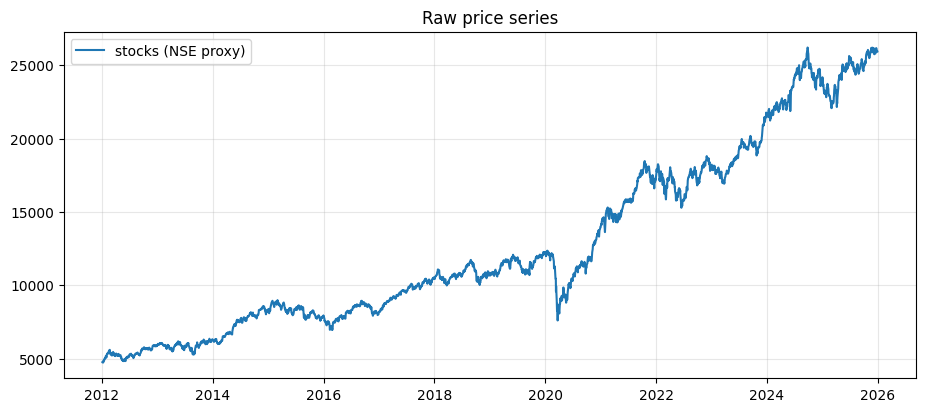

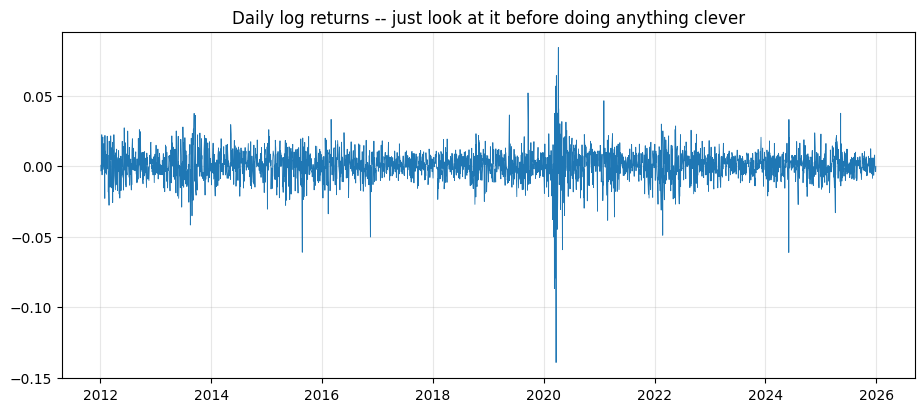

In [4]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices["stocks"], label="stocks (NSE proxy)")
ax.set_title("Raw price series")
ax.legend()
plt.show()

log_returns = np.log(prices["stocks"]).diff().dropna()
fig, ax = plt.subplots()
ax.plot(log_returns.index, log_returns, lw=0.6)
ax.set_title("Daily log returns -- just look at it before doing anything clever")
plt.show()


---
## Phase 2 — Engineer Features That Describe the Market's State
Momentum (1w / 1m / 1q rolling windows) + volatility (rolling std, annualized) + the VIX level/change as a fear proxy. We sanity-check that the volatility feature actually spikes in known stress periods.


In [5]:
def build_features(prices: pd.DataFrame) -> pd.DataFrame:
    ret = np.log(prices["stocks"]).diff()
    feat = pd.DataFrame(index=prices.index)
    feat["mom_1w"] = ret.rolling(5).sum()
    feat["mom_1m"] = ret.rolling(21).sum()
    feat["mom_1q"] = ret.rolling(63).sum()
    feat["vol_1m"] = ret.rolling(21).std() * np.sqrt(252)
    feat["vol_1w"] = ret.rolling(5).std() * np.sqrt(252)
    feat["vix_level"] = prices["vix"]
    feat["vix_chg_1w"] = prices["vix"].pct_change(5)
    feat["ret_1d"] = ret
    return feat.dropna()

FEATURE_COLS = ["mom_1w", "mom_1m", "mom_1q", "vol_1m", "vol_1w", "vix_level", "vix_chg_1w"]

features = build_features(prices)
features.tail()


,mom_1w,mom_1m,mom_1q,vol_1m,vol_1w,vix_level,vix_chg_1w,ret_1d
Date,,,,,,,,
2025-12-23,0.012186,0.004173,0.033014,0.083900,0.066086,9.38,-0.067594,0.000181
2025-12-24,0.012454,0.007009,0.036610,0.082601,0.065071,9.19,-0.066057,-0.001340
2025-12-26,0.008745,0.006066,0.034089,0.083127,0.078395,9.15,-0.057673,-0.003825
2025-12-29,-0.000936,-0.010095,0.034718,0.071765,0.076785,9.72,0.021008,-0.003855
2025-12-30,-0.008964,-0.010130,0.041242,0.071762,0.031012,9.68,0.000000,-0.000125


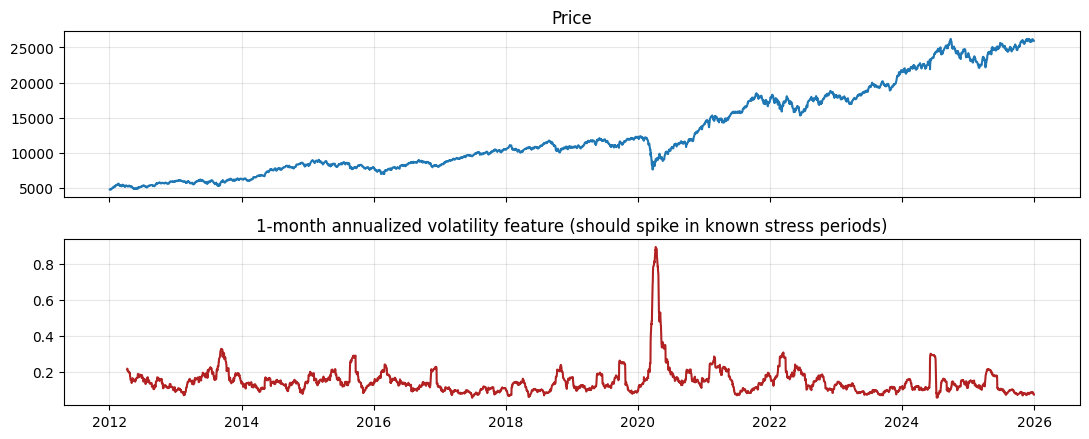

In [6]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(prices.index, prices["stocks"]); axes[0].set_title("Price")
axes[1].plot(features.index, features["vol_1m"], color="firebrick")
axes[1].set_title("1-month annualized volatility feature (should spike in known stress periods)")
plt.tight_layout(); plt.show()


---
## Phase 3 — Build the Regime Classifier (HMM)
Fit a 3-state Gaussian HMM (`hmmlearn`) on the engineered features. The HMM only returns state numbers 0/1/2 — we label them Bull / Bear / Crisis by ranking mean volatility per state. This first fit is **in-sample** (fit on the whole series) purely so we can eyeball whether the regimes line up with periods we already know were turbulent — it is *not* the version used in the backtest (that comes from the walk-forward section next).


In [7]:
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

def fit_hmm(X_scaled, n_states=3, seed=RNG_SEED):
    model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200, random_state=seed)
    model.fit(X_scaled)
    return model

def label_states_by_volatility(model, vol_col_idx):
    means = model.means_[:, vol_col_idx]
    order = np.argsort(means)
    return {order[0]: "Bull", order[1]: "Bear", order[2]: "Crisis"}

X = features[FEATURE_COLS].values
X_scaled = StandardScaler().fit_transform(X)
model_full = fit_hmm(X_scaled)
vol_idx = FEATURE_COLS.index("vol_1m")
mapping_full = label_states_by_volatility(model_full, vol_idx)
states_full = model_full.predict(X_scaled)
labels_full = pd.Series([mapping_full[s] for s in states_full], index=features.index)

trans_df = pd.DataFrame(model_full.transmat_,
                         index=[mapping_full[i] for i in range(3)],
                         columns=[mapping_full[i] for i in range(3)]).reindex(
                         index=["Bull","Bear","Crisis"], columns=["Bull","Bear","Crisis"])
print("Transition probability matrix (in-sample fit):")
trans_df.round(3)


Transition probability matrix (in-sample fit):


,Bull,Bear,Crisis
Bull,0.971,0.029,0.000
Bear,0.020,0.972,0.008
Crisis,0.000,0.050,0.950


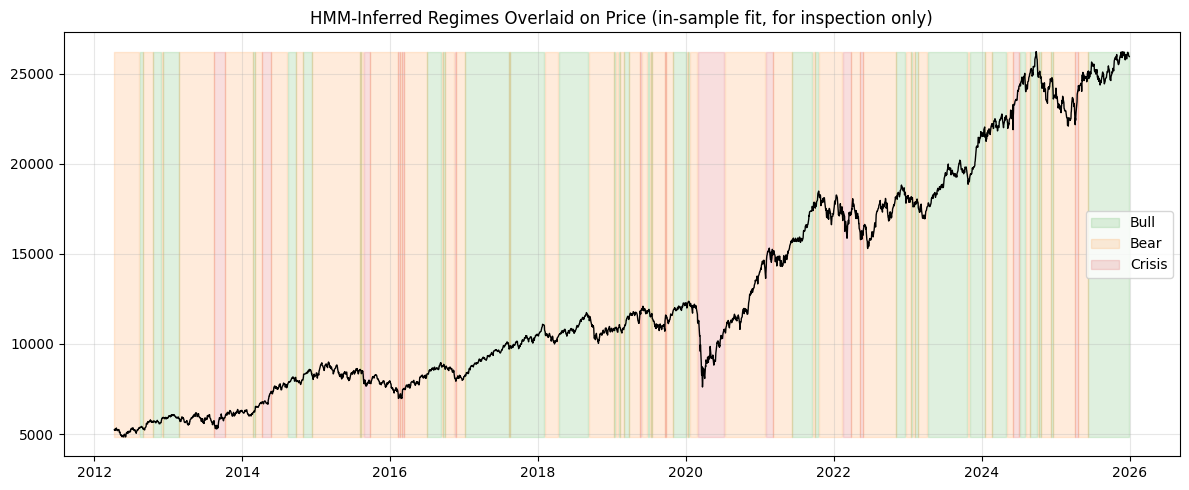

In [8]:
colors = {"Bull": "#2ca02c", "Bear": "#ff7f0e", "Crisis": "#d62728"}
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prices.loc[features.index, "stocks"], color="black", lw=1)
for regime, c in colors.items():
    mask = labels_full == regime
    ax.fill_between(features.index, prices.loc[features.index, "stocks"].min(),
                     prices.loc[features.index, "stocks"].max(), where=mask.values, color=c, alpha=0.15, label=regime)
ax.set_title("HMM-Inferred Regimes Overlaid on Price (in-sample fit, for inspection only)")
ax.legend(); plt.tight_layout(); plt.show()


---
## Phase 4 — Test It Properly: Walk-Forward Validation
This is the part the project statement calls "the hard and genuinely interesting part." We slide a rolling train/test window through time. Inside each window:
- The `StandardScaler` is **fit only on the training slice**, then used to `.transform()` the test slice.
- The HMM is **re-fit from scratch on the training slice only**.
- The trained (train-only) HMM then `.predict()`s regimes for the *test* slice — it never sees test-period data during fitting.

A regime label assigned to a given day therefore never depends on data from after that day. This out-of-sample regime series is what feeds the backtest below (not the in-sample fit above).


In [9]:
def walk_forward_regimes(features, train_size=504, test_size=63, n_states=3):
    X = features[FEATURE_COLS].values
    idx = features.index
    n = len(features)

    out_regimes = pd.Series(index=idx, dtype=object)
    transition_matrices = []

    start = 0
    while start + train_size + 1 < n:
        train_end = start + train_size
        test_end = min(train_end + test_size, n)

        X_train, X_test = X[start:train_end], X[train_end:test_end]

        scaler = StandardScaler().fit(X_train)       # TRAIN ONLY
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)           # transform only, no fit

        model = fit_hmm(X_train_s, n_states=n_states)
        mapping = label_states_by_volatility(model, FEATURE_COLS.index("vol_1m"))

        pred_test_states = model.predict(X_test_s)    # decode test window with train-fit params only
        out_regimes.iloc[train_end:test_end] = [mapping[s] for s in pred_test_states]
        transition_matrices.append(model.transmat_)
        start += test_size

    return out_regimes.dropna(), transition_matrices


wf_regimes, wf_trans_mats = walk_forward_regimes(features, train_size=504, test_size=63)
print(f"Out-of-sample regime-labeled days: {len(wf_regimes)}")
wf_regimes.value_counts()


Out-of-sample regime-labeled days: 2763


,count
Bear,1162
Bull,1048
Crisis,553


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


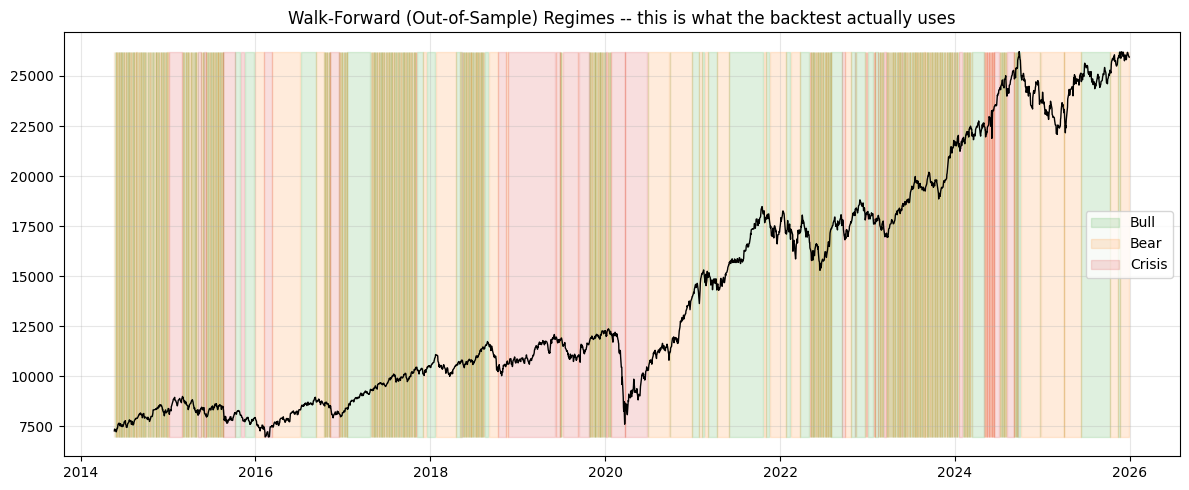

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prices.loc[wf_regimes.index, "stocks"], color="black", lw=1)
for regime, c in colors.items():
    mask = wf_regimes == regime
    ax.fill_between(wf_regimes.index, prices.loc[wf_regimes.index, "stocks"].min(),
                     prices.loc[wf_regimes.index, "stocks"].max(), where=mask.values, color=c, alpha=0.15, label=regime)
ax.set_title("Walk-Forward (Out-of-Sample) Regimes -- this is what the backtest actually uses")
ax.legend(); plt.tight_layout(); plt.show()


---
## Phase 5 — Connect Regimes to Portfolio Decisions (Convex Optimization)
For each rebalance date we solve a mean-variance quadratic program with `cvxpy`, using **only trailing (past) return data** to estimate `mu` and `Sigma`. The regime sets the risk-aversion `gamma`:

| Regime | Objective in practice | `gamma` |
|---|---|---|
| Bull  | tilt toward return (higher Sharpe appetite) | 2  |
| Bear  | more balanced / defensive | 8  |
| Crisis | minimize-variance-like (capital preservation) | 30 |

Constraints: weights sum to 1, no shorting, max 70% in any single asset.


In [11]:
import cvxpy as cp

REGIME_GAMMA = {"Bull": 2.0, "Bear": 8.0, "Crisis": 30.0}
MAX_WEIGHT = 0.70

def optimize_weights(mu, sigma, regime):
    n = len(mu)
    w = cp.Variable(n)
    gamma = REGIME_GAMMA[regime]
    objective = cp.Maximize(mu @ w - gamma * cp.quad_form(w, cp.psd_wrap(sigma)))
    constraints = [cp.sum(w) == 1, w >= 0, w <= MAX_WEIGHT]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    if w.value is None:
        return np.array([1/n]*n)
    wv = np.clip(w.value, 0, None)
    return wv / wv.sum()

print("Convex optimizer ready (per-regime risk aversion via gamma).")


Convex optimizer ready (per-regime risk aversion via gamma).


---
## Phase 6 — Backtest (with Transaction Costs) vs Static Benchmarks
- **Smooth the regime series first.** The raw walk-forward HMM output decodes one day at a time and can legitimately flip on individual noisy days. A ~1-month (`window=21`) rolling-majority-vote smoothing pass turns that into a much steadier "what regime are we actually in" signal -- each point only uses days up to and including itself, so this adds no lookahead.
- **Rebalance on regime change, not a fixed clock**, with a hard `min_hold=21`-day floor between trades (caps worst-case turnover even if the smoothed series still chatters near a boundary) and a `max_hold=126`-day safety refresh so weights don't go stale during an unusually long, stable regime.
- Each triggered rebalance re-estimates `mu`/`Sigma` from the trailing 63-day window (past data only) and re-solves the convex program using the current regime.
- A transaction cost of **7 bps** is applied to turnover (`sum(|Δweight|)`) whenever a rebalance actually fires.
- Benchmarks: static **60/40** (stocks/bonds) and **equal-weight** (1/3 each), still rebalanced monthly since they have no regime signal to react to -- that schedule is held constant so we aren't tuning the benchmarks' behavior at the same time as the strategy's.


In [12]:
def smooth_regimes(regimes, window=21):
    """Rolling-mode smoothing: turns noisy day-to-day HMM decodes into a
    steadier regime signal. Each point only looks at itself and the past,
    so this introduces no lookahead."""
    vals = regimes.values
    out = np.empty(len(vals), dtype=object)
    for i in range(len(vals)):
        start = max(0, i - window + 1)
        window_vals = vals[start:i + 1]
        uniq, counts = np.unique(window_vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return pd.Series(out, index=regimes.index)


wf_regimes_smoothed = smooth_regimes(wf_regimes, window=21)
print(f"Raw daily regime changes: {(wf_regimes != wf_regimes.shift()).sum()}  ->  "
      f"Smoothed regime changes: {(wf_regimes_smoothed != wf_regimes_smoothed.shift()).sum()}")


Raw daily regime changes: 979  ->  Smoothed regime changes: 548


In [13]:
def performance_stats(returns):
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    downside = returns[returns < 0]
    down_vol = downside.std() * np.sqrt(252) if len(downside) else np.nan
    sortino = ann_ret / down_vol if down_vol and down_vol > 0 else np.nan
    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return dict(ann_return=ann_ret, ann_vol=ann_vol, sharpe=sharpe, sortino=sortino,
                max_drawdown=max_dd, calmar=calmar)


def backtest_dynamic(prices, regimes, lookback=63, min_hold=21, max_hold=126, cost_bps=7):
    """Rebalances on regime CHANGE, with a hard min_hold floor between
    trades (bounds worst-case turnover) and a max_hold safety refresh
    (keeps weights from going stale in a long, calm regime). `regimes`
    should already be smoothed via smooth_regimes()."""
    assets = ["stocks", "gold", "bonds"]
    rets = np.log(prices[assets]).diff().dropna()
    rets = rets.loc[regimes.index.intersection(rets.index)]
    regimes = regimes.loc[rets.index]

    dates = rets.index
    weights_hist = pd.DataFrame(index=dates, columns=assets, dtype=float)
    w_prev = np.array([1/3, 1/3, 1/3])
    turnover = pd.Series(0.0, index=dates)
    rebalance_dates = []
    current_regime = None
    days_since_rebal = 0

    for i, d in enumerate(dates):
        days_since_rebal += 1
        if i >= lookback:
            regime_today = regimes.iloc[i]
            can_rebalance = days_since_rebal >= min_hold
            trigger = current_regime is None or (
                can_rebalance and (regime_today != current_regime or days_since_rebal >= max_hold)
            )
            if trigger:
                window = rets.iloc[i - lookback:i]        # PAST DATA ONLY
                mu = window.mean().values * 252
                sigma = window.cov().values * 252
                w_new = optimize_weights(mu, sigma, regime_today)
                turnover.iloc[i] = np.abs(w_new - w_prev).sum()
                w_prev = w_new
                current_regime = regime_today
                days_since_rebal = 0
                rebalance_dates.append(d)
        weights_hist.iloc[i] = w_prev

    gross_ret = (weights_hist.shift(1).fillna(1/3) * rets).sum(axis=1)
    net_ret = gross_ret - turnover * (cost_bps / 10000)
    print(f"[backtest] dynamic strategy rebalanced {len(rebalance_dates)} times over "
          f"{len(dates)} trading days ({len(rebalance_dates)/(len(dates)/252):.1f}/year)")
    return net_ret, weights_hist, turnover


def backtest_static(prices, weights, rebalance_every=21, cost_bps=7):
    assets = list(weights.keys())
    w_target = np.array([weights[a] for a in assets])
    rets = np.log(prices[assets]).diff().dropna()
    dates = rets.index
    w_prev = w_target.copy()
    turnover = pd.Series(0.0, index=dates)
    weights_hist = pd.DataFrame(index=dates, columns=assets, dtype=float)
    for i, d in enumerate(dates):
        if i % rebalance_every == 0:
            turnover.iloc[i] = np.abs(w_target - w_prev).sum()
            w_prev = w_target.copy()
        weights_hist.iloc[i] = w_prev
    gross_ret = (weights_hist.shift(1).fillna(pd.Series(w_target, index=assets)) * rets).sum(axis=1)
    net_ret = gross_ret - turnover * (cost_bps / 10000)
    return net_ret, weights_hist, turnover


dyn_net, dyn_w, dyn_to = backtest_dynamic(prices, wf_regimes_smoothed, min_hold=21, max_hold=126, cost_bps=7)
dyn_gross, _, _ = backtest_dynamic(prices, wf_regimes_smoothed, min_hold=21, max_hold=126, cost_bps=0)
static_net, static_w, static_to = backtest_static(prices, {"stocks": 0.6, "gold": 0.0, "bonds": 0.4}, cost_bps=7)
eqw_net, eqw_w, eqw_to = backtest_static(prices, {"stocks": 1/3, "gold": 1/3, "bonds": 1/3}, cost_bps=7)

common_idx = dyn_net.index.intersection(static_net.index).intersection(eqw_net.index)
dyn_net, dyn_gross = dyn_net.loc[common_idx], dyn_gross.loc[common_idx]
static_net, eqw_net = static_net.loc[common_idx], eqw_net.loc[common_idx]
dyn_to = dyn_to.loc[common_idx]

results = {
    "Dynamic (regime-aware, net of costs)": performance_stats(dyn_net),
    "Dynamic (regime-aware, gross, no costs)": performance_stats(dyn_gross),
    "Static 60/40": performance_stats(static_net),
    "Equal-Weight (1/3 each)": performance_stats(eqw_net),
}
results_df = pd.DataFrame(results).T
results_df["turnover_annualized"] = np.nan
results_df.loc["Dynamic (regime-aware, net of costs)", "turnover_annualized"] = dyn_to.sum() / (len(dyn_to)/252)
results_df.loc["Static 60/40", "turnover_annualized"] = static_to.loc[common_idx].sum() / (len(common_idx)/252)
results_df.loc["Equal-Weight (1/3 each)", "turnover_annualized"] = eqw_to.loc[common_idx].sum() / (len(common_idx)/252)

results_df.round(4)


[backtest] dynamic strategy rebalanced 79 times over 2763 trading days (7.2/year)
[backtest] dynamic strategy rebalanced 79 times over 2763 trading days (7.2/year)


,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,turnover_annualized
"Dynamic (regime-aware, net of costs)",0.0775,0.1069,0.7247,0.9411,-0.1609,0.4814,4.2532
"Dynamic (regime-aware, gross, no costs)",0.0804,0.1069,0.7528,0.9768,-0.1587,0.5069,NaN
Static 60/40,0.0764,0.0998,0.7655,0.9267,-0.2345,0.3257,0.0000
Equal-Weight (1/3 each),0.0814,0.0816,0.9982,1.3633,-0.1477,0.5513,0.0000


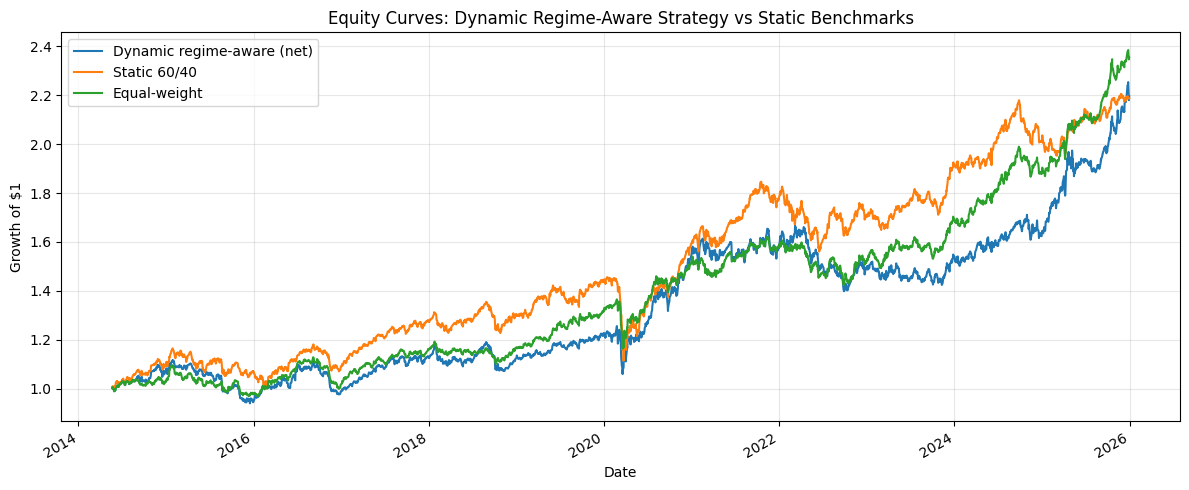

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
(1 + dyn_net).cumprod().plot(ax=ax, label="Dynamic regime-aware (net)")
(1 + static_net).cumprod().plot(ax=ax, label="Static 60/40")
(1 + eqw_net).cumprod().plot(ax=ax, label="Equal-weight")
ax.set_title("Equity Curves: Dynamic Regime-Aware Strategy vs Static Benchmarks")
ax.set_ylabel("Growth of $1")
ax.legend(); plt.tight_layout(); plt.show()


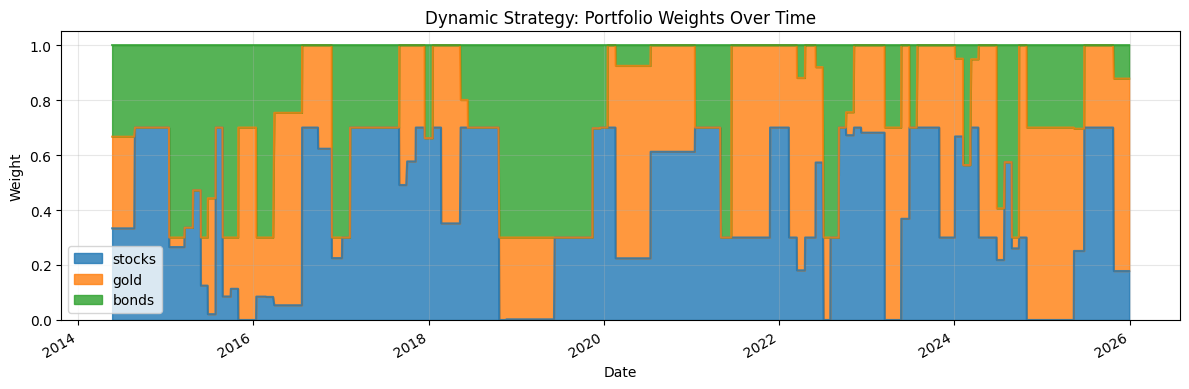

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
dyn_w.loc[common_idx].plot.area(ax=ax, alpha=0.8)
ax.set_title("Dynamic Strategy: Portfolio Weights Over Time")
ax.set_ylabel("Weight")
plt.tight_layout(); plt.show()


In [16]:
final_dyn = (1 + dyn_net).cumprod().iloc[-1]
final_static = (1 + static_net).cumprod().iloc[-1]
final_eqw = (1 + eqw_net).cumprod().iloc[-1]

print(f"Dynamic (regime-aware):  {final_dyn:.3f}x  ->  {(final_dyn - 1) * 100:.1f}% cumulative return")
print(f"Static 60/40:            {final_static:.3f}x  ->  {(final_static - 1) * 100:.1f}% cumulative return")
print(f"Equal-weight:            {final_eqw:.3f}x  ->  {(final_eqw - 1) * 100:.1f}% cumulative return")

Dynamic (regime-aware):  2.196x  ->  119.6% cumulative return
Static 60/40:            2.187x  ->  118.7% cumulative return
Equal-weight:            2.354x  ->  135.4% cumulative return
